ARIMA MODEL FORCASTING

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('/content/Data1.csv',index_col='DATE',parse_dates=True)
df=df.dropna()
print('Shape of data',df.shape)
df.head()

Shape of data (1821, 5)


,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,
2014-01-01,33.0,46.0,40.0,657,1756
2014-01-02,35.0,50.0,43.0,657,1756
2014-01-03,36.0,45.0,41.0,657,1757
2014-01-04,32.0,41.0,37.0,658,1757
2014-01-05,24.0,38.0,31.0,658,1758


<Axes: xlabel='DATE'>

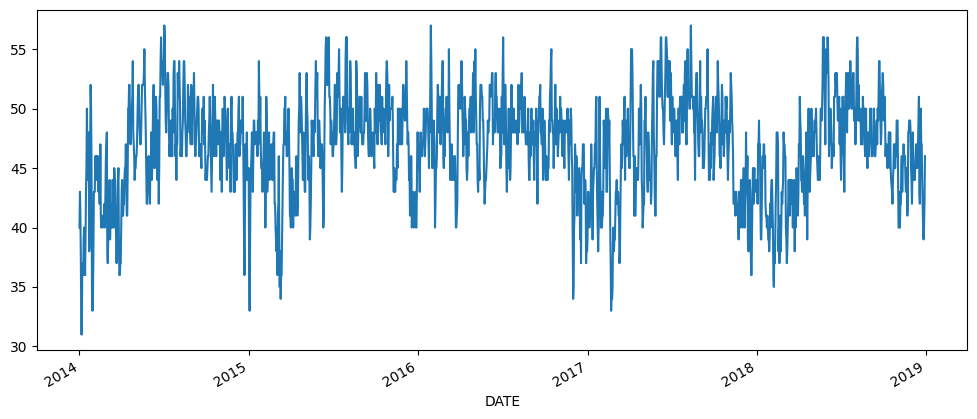

In [3]:
df['AvgTemp'].plot(figsize=(12,5))

In [4]:
from statsmodels.tsa.stattools import adfuller

def adf_test(dataset):
  dftest = adfuller(dataset, autolag = 'AIC')
  print("1. ADF : ",dftest[0])
  print("2. P-Value : ", dftest[1])
  print("3. Num Of Lags : ", dftest[2])
  print("4. Num Of Observations Used For ADF Regression and Critical Values Calculation :", dftest[3])
  print("5. Critical Values :")
  for key, val in dftest[4].items():
      print("\t",key, ": ", val)

In [5]:
adf_test(df['AvgTemp'])

1. ADF :  -6.5546801250687805
2. P-Value :  8.675937480199557e-09
3. Num Of Lags :  12
4. Num Of Observations Used For ADF Regression and Critical Values Calculation : 1808
5. Critical Values :
	 1% :  -3.433972018026501
	 5% :  -2.8631399192826676
	 10% :  -2.5676217442756872


In [ ]:
!pip install pmdarima

In [9]:
from pmdarima import auto_arima
import warnings
warnings.filterwarnings("ignore")

In [10]:
stepwise_fit = auto_arima(df['AvgTemp'],trace = True ,
                          suppress_warnings=True)

stepwise_fit.summary()

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=8344.294, Time=5.69 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=10347.755, Time=0.06 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=8365.701, Time=0.31 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=9136.225, Time=0.40 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=19192.139, Time=0.04 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=8355.947, Time=2.22 sec
 ARIMA(2,0,1)(0,0,0)[0] intercept   : AIC=8356.308, Time=6.02 sec
 ARIMA(3,0,2)(0,0,0)[0] intercept   : AIC=8347.324, Time=3.94 sec
 ARIMA(2,0,3)(0,0,0)[0] intercept   : AIC=8318.606, Time=3.90 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=8330.189, Time=5.67 sec
 ARIMA(3,0,3)(0,0,0)[0] intercept   : AIC=8310.514, Time=4.64 sec
 ARIMA(4,0,3)(0,0,0)[0] intercept   : AIC=8332.054, Time=5.64 sec
 ARIMA(3,0,4)(0,0,0)[0] intercept   : AIC=8317.589, Time=6.63 sec
 ARIMA(2,0,4)(0,0,0)[0] intercept   : AIC=8305.928, Time=5.13 sec
 ARIMA(1,0,4)(0,0,0)[0] interce

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                      y   No. Observations:                 1821
Model:               SARIMAX(1, 0, 5)   Log Likelihood               -4139.428
Date:                Tue, 02 Jun 2026   AIC                           8294.855
Time:                        05:43:07   BIC                           8338.912
Sample:                             0   HQIC                          8311.109
                               - 1821                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
intercept      1.2109      0.362      3.345      0.001       0.501       1.920
ar.L1          0.9739      0.008    124.763      0.000       0.959       0.989
ma.L1         -0.1277      0.024     -5.399      0.000      -0.174      -0.081
ma.L2         -0.2152      0.024     -8.944      0.000      -0.262      -0.168
ma.L3         -0.2087      0.024     -8.768      0.000      -0.255      -0.162
ma.L4         -0.1387      0.023     -6.104      0.000      -0.183      -0.094
ma.L5         -0.0456      0.024     -1.874      0.061      -0.093       0.002
sigma2         5.4914      0.172     31.993      0.000       5.155       5.828
===================================================================================
Ljung-Box (L1) (Q):                   0.01   Jarque-Bera (JB):                20.06
Prob(Q):                              0.94   Prob(JB):                         0.00
Heteroskedasticity (H):               0.81   Skew:                            -0.17
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.38
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [11]:
from statsmodels.tsa.arima.model import ARIMA

In [12]:
print(df.shape)
train=df.iloc[:-30]
test=df.iloc[-30:]
print(train.shape,test.shape)
print(test.iloc[0],test.iloc[-1])

(1821, 5)
(1791, 5) (30, 5)
MinTemp      36.0
MaxTemp      52.0
AvgTemp      44.0
Sunrise     640.0
Sunset     1743.0
Name: 2018-12-01 00:00:00, dtype: float64 MinTemp      39.0
MaxTemp      52.0
AvgTemp      46.0
Sunrise     656.0
Sunset     1754.0
Name: 2018-12-30 00:00:00, dtype: float64


TRAINING THE MODEL

In [13]:
model=ARIMA(train['AvgTemp'],order=(1,0,5))
model=model.fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:                AvgTemp   No. Observations:                 1791
Model:                 ARIMA(1, 0, 5)   Log Likelihood               -4070.198
Date:                Tue, 02 Jun 2026   AIC                           8156.395
Time:                        05:44:18   BIC                           8200.320
Sample:                             0   HQIC                          8172.614
                               - 1791                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         46.5856      0.758     61.454      0.000      45.100      48.071
ar.L1          0.9856      0.005    188.230      0.000       0.975       0.996
ma.L1         -0.1412      0.023     -6.124      0.000      -0.186      -0.096
ma.L2         -0.2268      0.024     -9.635      0.000      -0.273      -0.181
ma.L3         -0.2168      0.023     -9.251      0.000      -0.263      -0.171
ma.L4         -0.1479      0.023     -6.491      0.000      -0.193      -0.103
ma.L5         -0.0595      0.024     -2.438      0.015      -0.107      -0.012
sigma2         5.5093      0.174     31.624      0.000       5.168       5.851
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):                14.88
Prob(Q):                              0.97   Prob(JB):                         0.00
Heteroskedasticity (H):               0.82   Skew:                            -0.15
Prob(H) (two-sided):                  0.01   Kurtosis:                         3.33
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

<Axes: xlabel='DATE'>

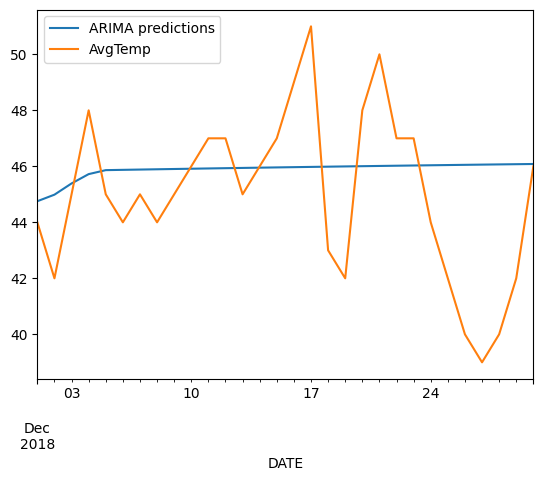

In [14]:
start=len(train)
end=len(train)+len(test)-1
#if the predicted values dont have date values as index, you will have to uncomment the following two commented lines to plot a graph
index_future_dates=pd.date_range(start='2018-12-01',end='2018-12-30')
pred=model.predict(start=start,end=end,typ='levels').rename('ARIMA predictions')
pred.index=index_future_dates
pred.plot(legend=True)
test['AvgTemp'].plot(legend=True)

In [15]:
test['AvgTemp'].mean()

np.float64(45.0)

In [16]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse=sqrt(mean_squared_error(pred,test['AvgTemp']))
print(rmse)

3.000463813911383


In [17]:
model2=ARIMA(df['AvgTemp'],order=(1,0,5))
model2=model2.fit()
df.tail()

,MinTemp,MaxTemp,AvgTemp,Sunrise,Sunset
DATE,,,,,
2018-12-26,35.0,45.0,40.0,654,1752
2018-12-27,33.0,44.0,39.0,655,1752
2018-12-28,33.0,47.0,40.0,655,1753
2018-12-29,36.0,47.0,42.0,655,1753
2018-12-30,39.0,52.0,46.0,656,1754


In [18]:
index_future_dates=pd.date_range(start='2018-12-30',end='2019-01-29')
#print(index_future_dates)
pred=model2.predict(start=len(df),end=len(df)+30,typ='levels').rename('ARIMA Predictions')
#print(comp_pred)
pred.index=index_future_dates
print(pred)

2018-12-30    46.418166
2018-12-31    46.113912
2019-01-01    45.617874
2019-01-02    45.249566
2019-01-03    45.116916
2019-01-04    45.136667
2019-01-05    45.156141
2019-01-06    45.175342
2019-01-07    45.194275
2019-01-08    45.212943
2019-01-09    45.231350
2019-01-10    45.249499
2019-01-11    45.267395
2019-01-12    45.285040
2019-01-13    45.302438
2019-01-14    45.319592
2019-01-15    45.336507
2019-01-16    45.353185
2019-01-17    45.369630
2019-01-18    45.385844
2019-01-19    45.401832
2019-01-20    45.417596
2019-01-21    45.433139
2019-01-22    45.448465
2019-01-23    45.463576
2019-01-24    45.478476
2019-01-25    45.493168
2019-01-26    45.507653
2019-01-27    45.521937
2019-01-28    45.536020
2019-01-29    45.549906
Freq: D, Name: ARIMA Predictions, dtype: float64


<Axes: xlabel='DATE'>

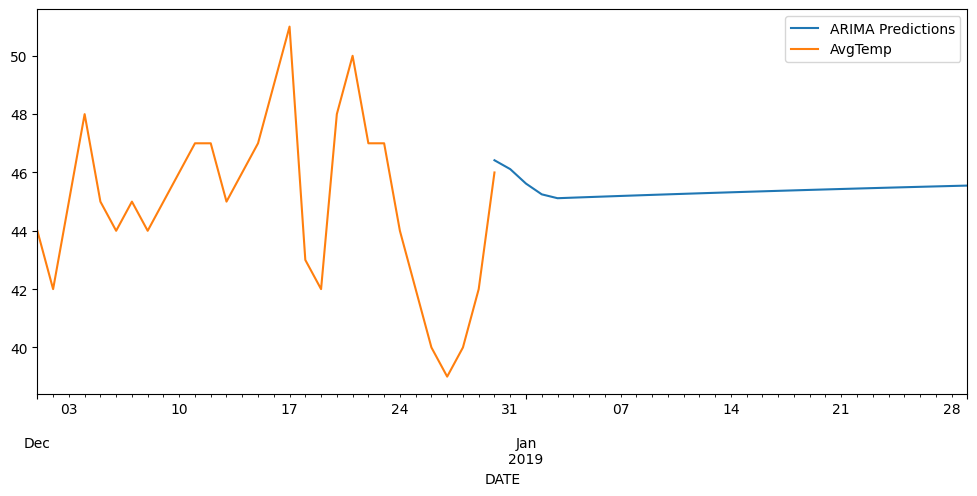

In [19]:
pred.plot(figsize=(12,5),legend=True)
test['AvgTemp'].plot(legend=True)

In [20]:
import matplotlib.pyplot as plt
from statsmodels.tsa.ar_model import AutoReg

In [23]:
df = pd.read_csv("Data2.csv",parse_dates = True)
df

,Date,temp
0,01/01/81,20.7
1,02/01/81,17.9
2,03/01/81,18.8
3,04/01/81,14.6
4,05/01/81,15.8
...,...,...
3645,27/12/90,14.0
3646,28/12/90,13.6
3647,29/12/90,13.5
3648,30/12/90,15.7


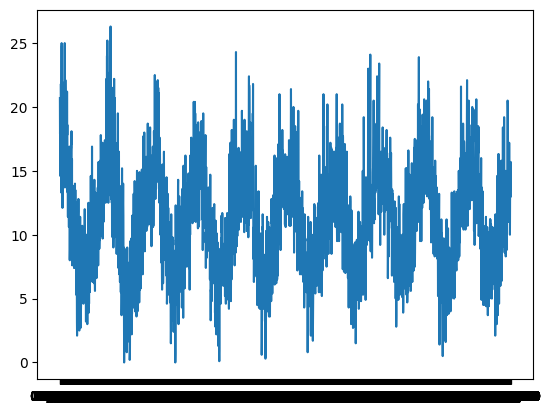

In [24]:
plt.plot(df['Date'],df['temp'])

In [25]:
from statsmodels.tsa.stattools import adfuller

dftest = adfuller(df['temp'],autolag = 'AIC')
dftest
# small p-value

(np.float64(-4.4448049246117),
 np.float64(0.0002470826300360994),
 20,
 3629,
 {'1%': np.float64(-3.4321532327220154),
  '5%': np.float64(-2.862336767636517),
  '10%': np.float64(-2.56719413172842)},
 np.float64(16642.822304301197))

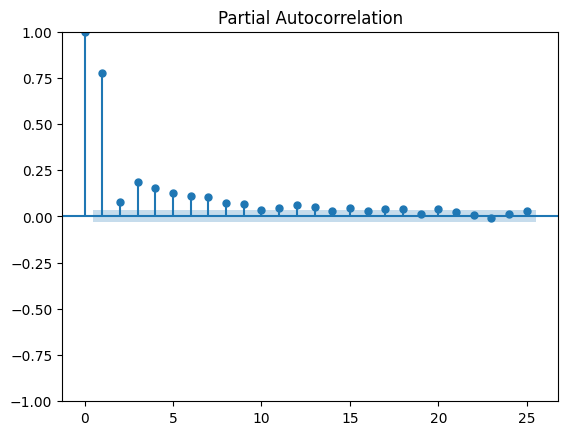

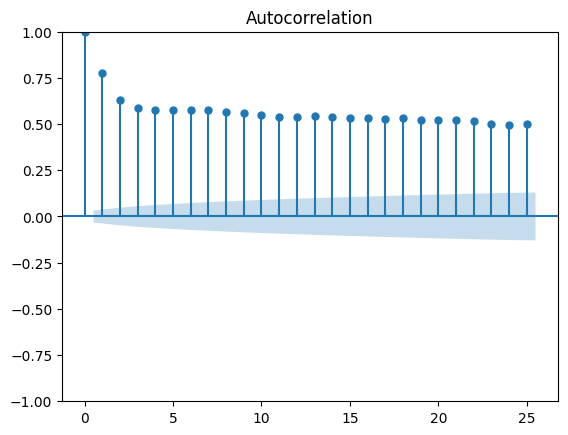

In [26]:
from statsmodels.graphics.tsaplots import plot_pacf,plot_acf
pacf = plot_pacf(df['temp'],lags = 25)
acf = plot_acf(df['temp'],lags = 25)

In [27]:
X = df['temp']

In [28]:
train= X[:len(X)-7]
test= X[len(X)-7:]

In [29]:
 train

,temp
0,20.7
1,17.9
2,18.8
3,14.6
4,15.8
...,...
3638,15.4
3639,13.1
3640,13.2
3641,13.9


In [30]:
test

,temp
3643,12.9
3644,14.6
3645,14.0
3646,13.6
3647,13.5
3648,15.7
3649,13.0


In [31]:
model = AutoReg(train,lags = 10).fit()
model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            AutoReg Model Results                             
==============================================================================
Dep. Variable:                   temp   No. Observations:                 3643
Model:                    AutoReg(10)   Log Likelihood               -8375.514
Method:               Conditional MLE   S.D. of innovations              2.427
Date:                Tue, 02 Jun 2026   AIC                          16775.028
Time:                        06:00:47   BIC                          16849.402
Sample:                            10   HQIC                         16801.521
                                 3643                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.9350      0.142      6.603      0.000       0.657       1.213
temp.L1        0.6103      0.017     36.795      0.000       0.578       0.643
temp.L2       -0.0832      0.019     -4.289      0.000      -0.121      -0.045
temp.L3        0.0631      0.019      3.246      0.001       0.025       0.101
temp.L4        0.0512      0.019      2.632      0.008       0.013       0.089
temp.L5        0.0547      0.019      2.810      0.005       0.017       0.093
temp.L6        0.0422      0.019      2.166      0.030       0.004       0.080
temp.L7        0.0590      0.019      3.032      0.002       0.021       0.097
temp.L8        0.0324      0.019      1.664      0.096      -0.006       0.070
temp.L9        0.0502      0.019      2.585      0.010       0.012       0.088
temp.L10       0.0360      0.017      2.175      0.030       0.004       0.069
                                    Roots                                     
==============================================================================
                   Real          Imaginary           Modulus         Frequency
------------------------------------------------------------------------------
AR.1             1.0275           -0.0000j            1.0275           -0.0000
AR.2             0.9811           -0.7934j            1.2617           -0.1082
AR.3             0.9811           +0.7934j            1.2617            0.1082
AR.4             0.4192           -1.3007j            1.3665           -0.2004
AR.5             0.4192           +1.3007j            1.3665            0.2004
AR.6            -0.4338           -1.3906j            1.4567           -0.2981
AR.7            -0.4338           +1.3906j            1.4567            0.2981
AR.8            -1.3012           -0.8676j            1.5639           -0.4064
AR.9            -1.3012           +0.8676j            1.5639            0.4064
AR.10           -1.7501           -0.0000j            1.7501           -0.5000
------------------------------------------------------------------------------
"""

In [32]:
pred  = model.predict(start = len(train),end = len(X)-1,dynamic = False)

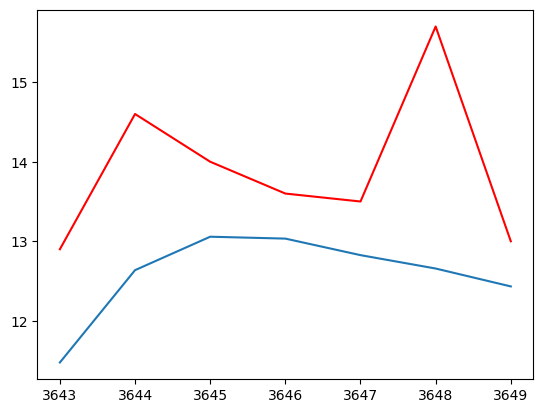

In [33]:
plt.plot(pred)
plt.plot(test,color = 'red')

In [34]:
from math import sqrt
from sklearn.metrics import mean_squared_error
rmse = sqrt(mean_squared_error(test,pred))

In [35]:
rmse

1.5638196220860838

Time Series Forcasting

In [37]:
df = pd.read_csv('Alcohol_Sales.csv',index_col='DATE',parse_dates=True)
df.index.freq = 'MS'

In [38]:
df.tail()

,S4248SM144NCEN
DATE,
2018-09-01,12396
2018-10-01,13914
2018-11-01,14174
2018-12-01,15504
2019-01-01,10718


<Axes: xlabel='DATE'>

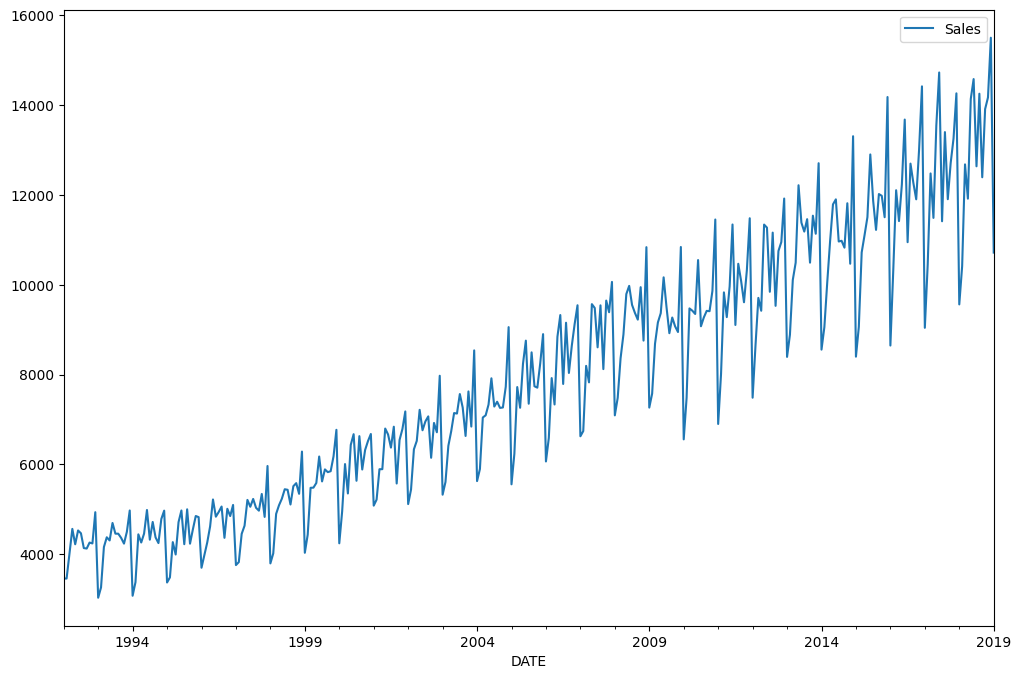

In [39]:
df.columns = ['Sales']
df.plot(figsize=(12,8))

In [50]:
df['Sale_LastMonth']=df['Sales'].shift(+1)
df['Sale_2Monthsback']=df['Sales'].shift(+2)
df['Sale_3Monthsback']=df['Sales'].shift(+3)
df.dropna(inplace=True)
df

,Sales,Sale_LastMonth,Sale_2Monthsback,Sale_3Monthsback
DATE,,,,
1992-04-01,4564,4002.0,3458.0,3459.0
1992-05-01,4221,4564.0,4002.0,3458.0
1992-06-01,4529,4221.0,4564.0,4002.0
1992-07-01,4466,4529.0,4221.0,4564.0
1992-08-01,4137,4466.0,4529.0,4221.0
...,...,...,...,...
2018-09-01,12396,14257.0,12640.0,14583.0
2018-10-01,13914,12396.0,14257.0,12640.0
2018-11-01,14174,13914.0,12396.0,14257.0


In [48]:
from sklearn.linear_model import LinearRegression
lin_model=LinearRegression()

In [42]:
from sklearn.ensemble import RandomForestRegressor
model=RandomForestRegressor(n_estimators=100,max_features=3, random_state=1)

In [51]:
import numpy as np
x1,x2,x3,y=df['Sale_LastMonth'],df['Sale_2Monthsback'],df['Sale_3Monthsback'],df['Sales']
x1,x2,x3,y=np.array(x1),np.array(x2),np.array(x3),np.array(y)
x1,x2,x3,y=x1.reshape(-1,1),x2.reshape(-1,1),x3.reshape(-1,1),y.reshape(-1,1)
final_x=np.concatenate((x1,x2,x3),axis=1)
print(final_x)

[[ 4002.  3458.  3459.]
 [ 4564.  4002.  3458.]
 [ 4221.  4564.  4002.]
 [ 4529.  4221.  4564.]
 [ 4466.  4529.  4221.]
 [ 4137.  4466.  4529.]
 [ 4126.  4137.  4466.]
 [ 4259.  4126.  4137.]
 [ 4240.  4259.  4126.]
 [ 4936.  4240.  4259.]
 [ 3031.  4936.  4240.]
 [ 3261.  3031.  4936.]
 [ 4160.  3261.  3031.]
 [ 4377.  4160.  3261.]
 [ 4307.  4377.  4160.]
 [ 4696.  4307.  4377.]
 [ 4458.  4696.  4307.]
 [ 4457.  4458.  4696.]
 [ 4364.  4457.  4458.]
 [ 4236.  4364.  4457.]
 [ 4500.  4236.  4364.]
 [ 4974.  4500.  4236.]
 [ 3075.  4974.  4500.]
 [ 3377.  3075.  4974.]
 [ 4443.  3377.  3075.]
 [ 4261.  4443.  3377.]
 [ 4460.  4261.  4443.]
 [ 4985.  4460.  4261.]
 [ 4324.  4985.  4460.]
 [ 4719.  4324.  4985.]
 [ 4374.  4719.  4324.]
 [ 4248.  4374.  4719.]
 [ 4784.  4248.  4374.]
 [ 4971.  4784.  4248.]
 [ 3370.  4971.  4784.]
 [ 3484.  3370.  4971.]
 [ 4269.  3484.  3370.]
 [ 3994.  4269.  3484.]
 [ 4715.  3994.  4269.]
 [ 4974.  4715.  3994.]
 [ 4223.  4974.  4715.]
 [ 5000.  4223. 

In [52]:
X_train,X_test,y_train,y_test=final_x[:-30],final_x[-30:],y[:-30],y[-30:]

In [53]:
model.fit(X_train,y_train)
lin_model.fit(X_train,y_train)

LinearRegression()

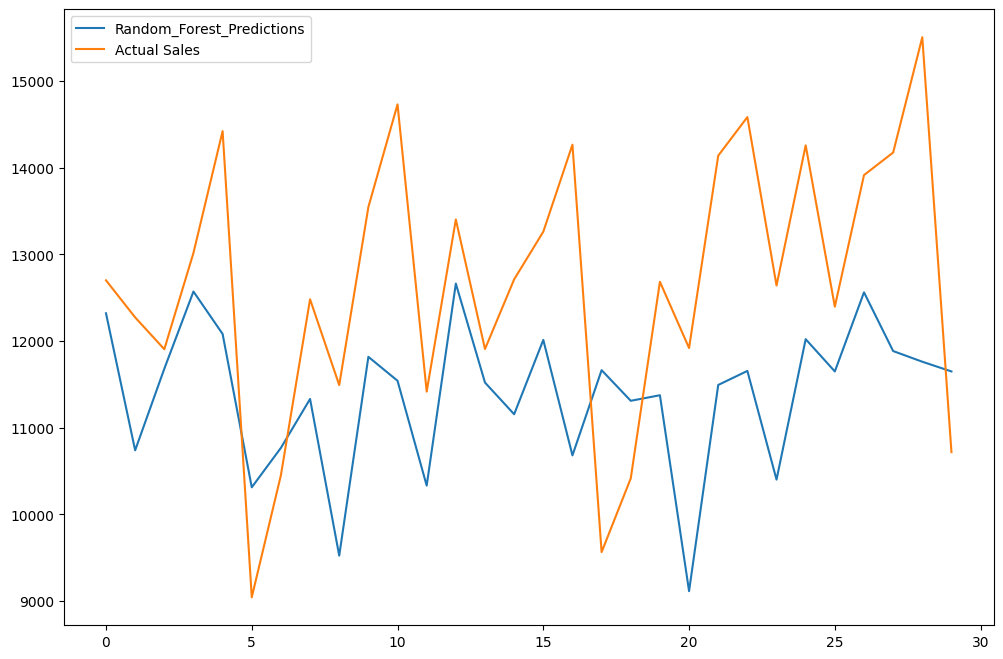

In [54]:
pred=model.predict(X_test)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (12,8)
plt.plot(pred,label='Random_Forest_Predictions')
plt.plot(y_test,label='Actual Sales')
plt.legend(loc="upper left")
plt.show()

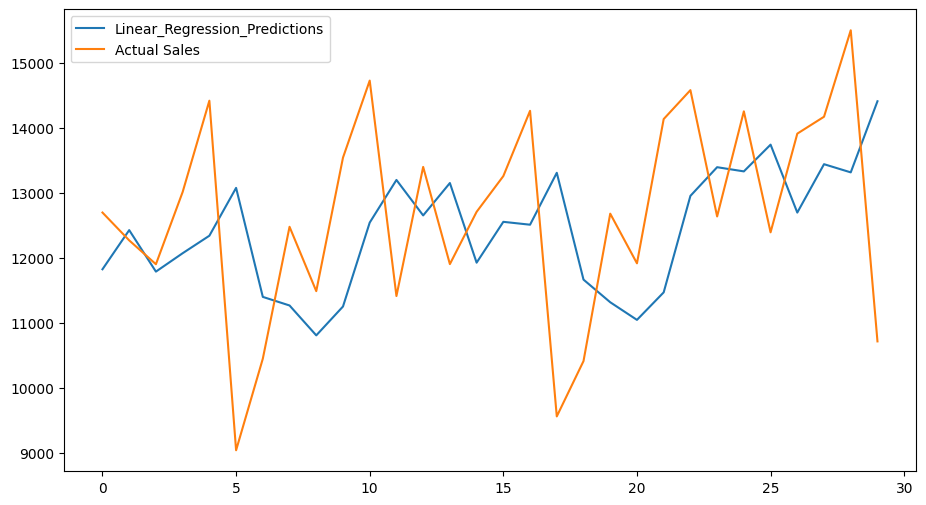

In [55]:
lin_pred=lin_model.predict(X_test)
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (11,6)
plt.plot(lin_pred,label='Linear_Regression_Predictions')
plt.plot(y_test,label='Actual Sales')
plt.legend(loc="upper left")
plt.show()

In [56]:
from sklearn.metrics import mean_squared_error
from math import sqrt
rmse_rf=sqrt(mean_squared_error(pred,y_test))
rmse_lr=sqrt(mean_squared_error(lin_pred,y_test))

In [57]:
print('Mean Squared Error for Random Forest Model is:',rmse_rf)
print('Mean Squared Error for Linear Regression Model is:',rmse_lr)

Mean Squared Error for Random Forest Model is: 1913.7762399350665
Mean Squared Error for Linear Regression Model is: 1791.496523275983
